# Vodafone Music Subscription Prediction

## Sprint 1 - Initial Data Exploration

Goal of this notebook:

Perform initial data exploration and analyze target distribution.


### 1. Business Problem

We predict whether a subscriber will purchase the Music service.

Target variable:
- 1 - subscribed
- 0 - not subscribed

Business impact:
- False Negative → lose potential paying customer
- False Positive → marketing budget waste

### 2. Data Loading

Load dataset and check its basic structure.

In [2]:
# Встановлення необхідних бібліотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Завантаження датасету
df = pd.read_csv('../data/raw/music.csv')

### 3. Initial Data Inspection

We inspect:
- first rows
- dataset shape
- feature types

In [4]:
# Виведення перших 5 рядків датасету
display(df.head())

# Виведення розмірності датасету
print(df.shape)

# Виведення типів даних датасету
print(df.info())

,id,target,device_type,manufacturer_category,os_category,sim_count,tp_flag,lt,block_flag,days_exp,...,service_5_count_m3,service_6_count_m3,service_7_cost_m3,service_7_flag_m3,service_8_count_m3,income_brnd_cont_m3,data_type_1_m3,data_type_2_m3,data_type_3_m3,service_9_flag_m3
0,48104912810,0,7,1514,3,1.0,0,0.496508,0,299.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,13762.315646,1292.468784,NaN
1,4851497268,0,4,896,28,1.0,0,0.881540,0,189.0,...,11.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.000053,NaN
2,4877823097,0,7,592,3,2.0,0,0.811192,0,347.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.000977,NaN
3,4830183791,0,7,1756,3,2.0,0,0.928449,1,343.0,...,66.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.006680,NaN
4,48103940036,0,4,1057,28,1.0,0,0.578654,0,355.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.002487,1.0


(70000, 461)
<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Columns: 461 entries, id to service_9_flag_m3
dtypes: float64(452), int64(9)
memory usage: 246.2 MB
None


#### Dataset Overview

The dataset contains:

- 70,000 observations
- 461 features
- 9 integer features
- 452 float features

Memory usage: ~246.2 MB


### 4. Missing Values

In [ ]:
# Виведення середньої кількості відсутніх значень у колонках
missing = df.isna().mean().sort_values(ascending=False)
print(missing.head(10))

# Виведення кількості колонок, у яких відсоткова кількість відсутніх значень перевищує 50%
print((missing > 0.5).sum())

count_url_category_13    0.992771
count_url_category_15    0.987029
vol_app_3                0.986643
count_app_3              0.986643
count_url_category_12    0.983129
vol_app_11               0.977329
count_app_11             0.977329
count_app_13             0.973143
vol_app_13               0.973143
count_url_category_1     0.972186
dtype: float64
62


#### Observations

Several features contain extremely high missing ratios (above 95%).

For example:
- count_url_category_13 → 99.3% missing
- vol_app_3 → 98.6% missing

Out of 461 total features, 62 columns (≈13%) contain more than 50% missing values.
This indicates a significant sparsity issue in the dataset.

#### Implication

Features with more than 90–95% missing values will likely be removed 
during the Data Cleaning stage, as they provide minimal signal and 
may introduce noise into the model.

Such sparsity may increase model complexity and risk of overfitting, 
especially given the high dimensionality of the dataset.


### 5. Target Distribution

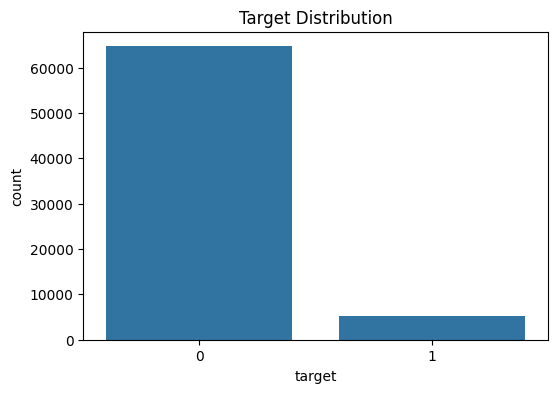

target
0    0.924271
1    0.075729
Name: proportion, dtype: float64
target
0    64699
1     5301
Name: count, dtype: int64


In [6]:
# Побудова графіку розподілу цільової змінної
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

# Виведення відсоткового співвідношення кількості підписаних клієнтів (1) та не підписаних (0)
print(df['target'].value_counts(normalize=True))

# Виведення кількості підписаних клієнтів (1) та не підписаних (0)
print(df['target'].value_counts())

#### Observations

The dataset is highly imbalanced.

- Class 0 (no subscription) represents 92.43% of the data.
- Class 1 (subscription) represents only 7.57%.

This indicates a strong class imbalance.

#### Implications

Accuracy will not be a reliable metric, as a naive model predicting only class 0 would achieve over 92% accuracy.

Therefore, evaluation metrics such as ROC-AUC, F1-score, and Recall will be more appropriate for this task.

Class imbalance handling techniques may be required during modeling.


### 6. Correlation Analysis

Топ позитивних факторів:
content_count_m1     0.116450
vol_app_11           0.112219
content_count_m3     0.111245
count_app_11         0.103440
content_count_m2     0.094392
count_gift_type_3    0.081626
count_app_5          0.076582
count_act_type_6     0.073582
rr_gift_type_3       0.062174
paym_count_m1        0.059475
Name: target, dtype: float64

Топ негативних факторів:
is_obl_center        -0.045522
service_1_count      -0.046068
service_P_flag_m1    -0.058425
count_act_type_1     -0.062009
count_gift_type_1    -0.063975
count_sms_source_5   -0.066107
count_act_type_7     -0.066916
service_P_flag_m2    -0.080735
service_P_flag_m3    -0.099962
lt                   -0.186401
Name: target, dtype: float64


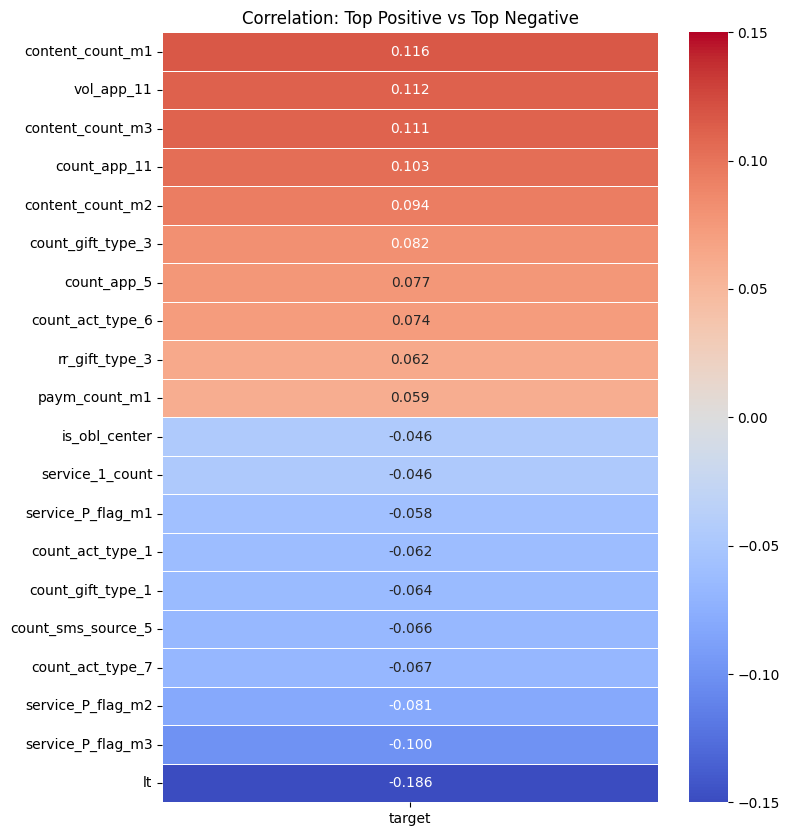

In [7]:
# Видалення ID (просто номер)
df_clean = df.drop(columns=['id'])

# Розрахунок кореляції з target
corr = df_clean.corr()['target'].sort_values(ascending=False)

# Видалення пустих значення (NaN)
corr = corr.dropna()

# Топ-10 позитивних (пропускаємо першу, бо це сам target = 1.0)
top_positive = corr[1:11]

# Топ-10 негативних (останні 10 значень)
top_negative = corr[-10:]

# Виведення результатів кореліції
print("Топ позитивних факторів:")
print(top_positive)
print("\nТоп негативних факторів:")
print(top_negative)

# Об'єднання змінних для графіка
top_features = pd.concat([top_positive, top_negative])
corr_matrix_to_plot = top_features.to_frame(name='target')

# Побудова графіку
plt.figure(figsize=(8, 10))
sns.heatmap(
    corr_matrix_to_plot,
    annot=True,
    cmap='coolwarm',
    center=0,
    vmin=-0.15, vmax=0.15, # Фіксуємо межі, щоб кольори були контрастними
    fmt=".3f",             # 3 знаки після коми для точності
    linewidths=0.5
)
plt.title("Correlation: Top Positive vs Top Negative")
plt.show()

### Correlation Analysis: Business Interpretation

Overall, the observed correlations are relatively weak (max |corr| ≈ 0.19). Subscription decisions are
likely influenced by multiple interacting factors rather than a single variable.

---

### Top Positive Correlations

The strongest positive correlations are associated with:

- content_count_m1 / content_count_m2 / content_count_m3  
- vol_app_11  
- count_app_11  
- paym_count_m1  

These features appear to reflect **recent user activity and content consumption behavior**.

This suggests that users who are more active in consuming digital content,
using applications, or making payments are slightly more likely to subscribe
to the Music service.

Business hypothesis:
Higher engagement level → higher probability of subscription.

---

### Top Negative Correlations

The strongest negative correlation is observed for:

- lt (-0.186)

`lt` represents customer lifetime or tenure,
this suggests that longer-tenure customers are less likely to subscribe.

Business hypothesis:
Newer users may be more open to adopting additional services,
while long-term users may already have established usage patterns.

Other negatively correlated features:

- service_P_flag_m2 / service_P_flag_m3  
- count_act_type_*  
- count_sms_source_5  

These may indicate that certain service users or activity types
are associated with lower likelihood of subscription.

---

### Interpretation

Since all correlations are relatively small in magnitude,
the relationship between features and subscription is likely non-linear.

This suggests that tree-based models (Random Forest, Gradient Boosting)
may capture patterns better than purely linear approaches.